In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [63]:
df = pd.read_csv('../sample_data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

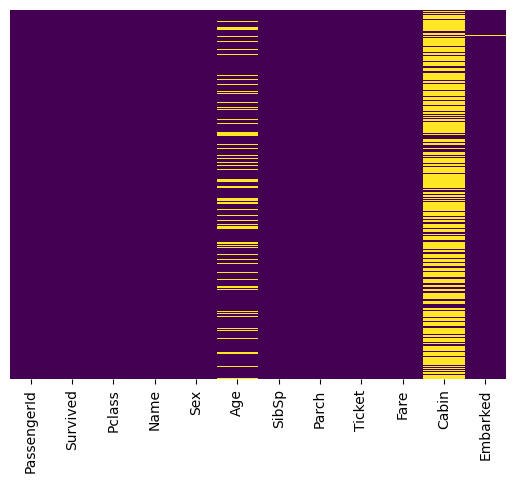

In [65]:
sns.heatmap(data = df.isnull(),yticklabels = False,cbar = False,cmap = 'viridis')

In [66]:
df.drop('Cabin',axis = 1,inplace = True)

<Axes: xlabel='Pclass', ylabel='Age'>

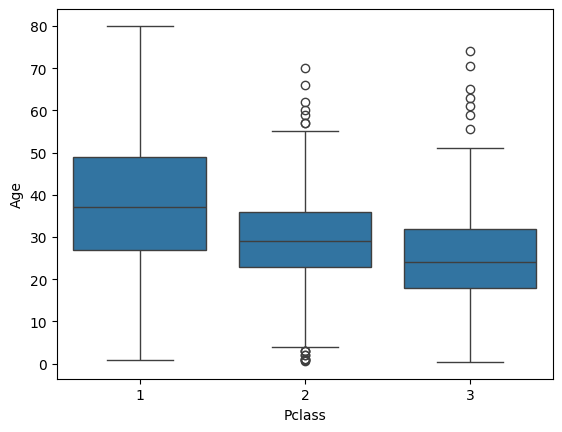

In [67]:
sns.boxplot(data = df,y = 'Age',x = 'Pclass')

In [68]:
#lets compute the age based on Pclass
mean_age_by_pclass = df.groupby('Pclass')['Age'].mean().round(1)
impute_dict = mean_age_by_pclass.to_dict()
print(impute_dict)

def impute_age_dynamic(cols,impute_dict):
    Age = cols[0]
    Pclass = cols[1]
    if pd.isnull(Age):
        return impute_dict.get(Pclass,Age)
    else:
        return Age
    
df['Age'] = df[['Pclass','Age']].apply(lambda row : impute_age_dynamic(row,impute_dict),axis = 1)


{1: 38.2, 2: 29.9, 3: 25.1}


C:\Users\megha\AppData\Local\Temp\ipykernel_31556\1892004192.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
C:\Users\megha\AppData\Local\Temp\ipykernel_31556\1892004192.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


<Axes: >

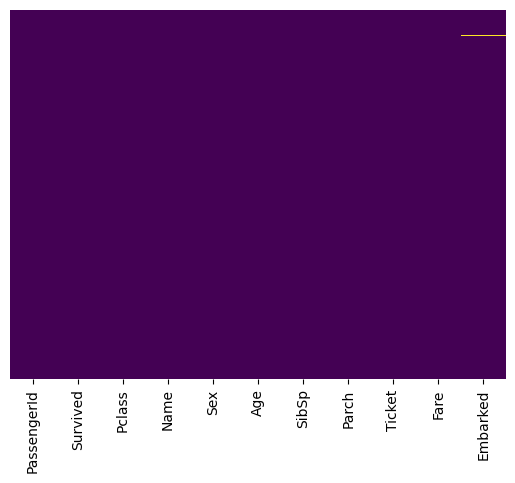

In [69]:
sns.heatmap(data = df.isnull(),cmap  = 'viridis',cbar = False,yticklabels = False)

In [70]:
df.dropna(subset = ['Embarked'],axis = 0,inplace = True)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [78]:
x= df.drop('Survived',axis = 1)
y = df.Survived

In [79]:

numerical_cols = [col for col in x.columns if x[col].dtype in ['int64','float64']]
print(numerical_cols)
categorical_cols = [col for col in x.columns if x[col].dtype == 'object']
print(categorical_cols)

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Name', 'Sex', 'Ticket', 'Embarked']


In [80]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state = 1)

In [84]:
#preprocess numerical data
numerical_transformer = SimpleImputer(strategy='constant')
#preprocess categorical data
categorical_transformer = Pipeline(steps = [('imputer',SimpleImputer(strategy='most_frequent')),('Onehot',OneHotEncoder(handle_unknown='ignore'))])
#bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(transformers=[('num',numerical_transformer,numerical_cols),('cat',categorical_transformer,categorical_cols)])

In [85]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
mypipeline = Pipeline(steps = [('preprocessor',preprocessor),('model',log_model)])

In [86]:
mypipeline.fit(x_train,y_train)
y_pred = mypipeline.predict(x_test)
mean_absolute_error(y_test,y_pred)

c:\Users\megha\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.1947565543071161

In [87]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[139  27]
 [ 25  76]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       166
           1       0.74      0.75      0.75       101

    accuracy                           0.81       267
   macro avg       0.79      0.79      0.79       267
weighted avg       0.81      0.81      0.81       267

